# Static Fe Kα / Kβ XES — mfx100895324 runs 36–54 (per-run)

Visualization for `examples/mfx100895324_static_xes.yaml` (reference data for **mfx102101026**).

Both emission lines are recorded on the **same detector** (`epix100_1`) at
different cross-dispersion rows:

| Line | Analyzer | d (Å) | Detector rows | ROI key |
|------|----------|-------|---------------|---------|
| Fe Kα | LiNbO3 (2 3 -4) | 0.981  | 228–248 | `epix_reduced_ROI_1` |
| Fe Kβ | Ge (6 2 0)      | 0.8946 | 158–180 | `epix_reduced_ROI_2` |

Static, within-run analysis (no laser). Reads the existing smalldata HDF5
files read-only. Shot counts vary by run (some runs are short, e.g. run 54
has only ~133 shots), so per-run intensities are **not** directly comparable
in raw counts — see the area-normalized and per-shot sections below.

In [1]:
import os, sys

# This notebook lives in <repo>/experiments/mfx100895324/. Add the XSpect repo
# root (two levels up) to sys.path so `from XSpect import ...` works without
# installing the package, regardless of the current working directory.
HERE = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT = os.path.abspath(os.path.join(HERE, '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from XSpect import Pipeline
import numpy as np
import matplotlib.pyplot as plt

YAML = os.path.join(HERE, 'mfx100895324_static_xes.yaml')
p = Pipeline.from_yaml(YAML)
# 20 cores (leaves headroom in a 24-core session). batch_size=1450 gives
# ~20 batches for the full ~28.8k-shot runs so all workers stay busy; short
# runs simply use fewer batches.
p.run(cores=20, batch_size=1450)

run_numbers = [r.run_number for r in p.analyzed_runs]
print(f'Runs processed ({len(run_numbers)}): {run_numbers}')

Runs processed (19): [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]


In [2]:
# Shared energy axes (identical geometry across runs).
ka_energy = p.results['kalpha_energy']   # (710,) eV
kb_energy = p.results['kbeta_energy']     # (710,) eV

runs = {r.run_number: r for r in p.analyzed_runs}
run_nums = sorted(runs)

# Per-run 1D spectra
ka = {rn: np.asarray(runs[rn].epix_reduced_ROI_1, dtype=float) for rn in run_nums}
kb = {rn: np.asarray(runs[rn].epix_reduced_ROI_2, dtype=float) for rn in run_nums}

# Per-run shot count (xray shots that made it through the pipeline)
shots = {rn: int(getattr(runs[rn], 'total_shots', 0)) for rn in run_nums}

print('run :  shots :  Kα sum      Kβ sum')
for rn in run_nums:
    print(f'{rn:4d} : {shots[rn]:6d} : {np.nansum(ka[rn]):.3e}  {np.nansum(kb[rn]):.3e}')

run :  shots :  Kα sum      Kβ sum
  36 :  28842 : 2.564e+06  1.063e+06
  37 :  28831 : 4.832e+06  1.700e+06
  38 :   1141 : 2.056e+05  7.067e+04
  39 :  28831 : 7.296e+05  5.465e+05
  40 :  28831 : 2.263e+06  9.889e+05
  41 :  28840 : 2.799e+06  1.144e+06
  42 :   2247 : 1.153e+05  4.053e+04
  43 :  28817 : 1.444e+06  7.743e+05
  44 :  28822 : 9.404e+05  6.251e+05
  45 :  28829 : 2.589e+06  1.085e+06
  46 :   3769 : 1.168e+05  8.271e+04
  47 :  14416 : 3.866e+04  3.766e+04
  48 :  28829 : 1.836e+06  8.645e+05
  49 :  28831 : 1.419e+06  7.688e+05
  50 :  21219 : 6.083e+05  4.371e+05
  51 :  28826 : 2.214e+06  1.013e+06
  52 :  18988 : 5.824e+05  4.168e+05
  53 :  28849 : 1.229e+06  7.306e+05
  54 :    133 : 3.743e+03  2.709e+03


In [3]:
# Sample composition loaded from the run manifest (runs.csv) -- the single
# source of truth documented in README.md. reduced_fraction = nominal Fe(II)
# ferrocyanide fraction (0 = pure ferricyanide reference, 1 = pure ferrocyanide).
# ocv_mV = open-circuit voltage recorded for the sample well (where noted).
# Run 47 is metallic Fe foil (calibration standard), NOT a cyanide sample, so
# it is excluded from all titration/deviation analysis and flagged separately.
# (Full beamtime record incl. Shift-2 in-situ echem is in BEAMTIME_MANIFEST.md.)
import csv

sample_label = {}
reduced_fraction = {}
ocv_mV = {}
role = {}
with open(os.path.join(HERE, 'runs.csv')) as fh:
    for row in csv.DictReader(fh):
        rn = int(row['run'])
        sample_label[rn] = row['sample_label']
        role[rn] = row['role']
        if row['reduced_fraction'] != '':
            reduced_fraction[rn] = float(row['reduced_fraction'])
        if row.get('ocv_mV', '') != '':
            ocv_mV[rn] = float(row['ocv_mV'])

FOIL_RUNS = [rn for rn, r in role.items() if r == 'excluded']   # Fe foil, excluded
chem_runs = [rn for rn in run_nums if rn not in FOIL_RUNS]      # cyanide samples only

# Oxidized reference = ALL ferricyanide runs (nominal Fe(II) fraction = 0),
# combined into one low-noise reference spectrum. This mirrors the reduced
# Fe(II) end-member (runs 39-42) used by the LCF, so both end-members are
# built the same way (sum raw counts -> area-normalize; see combined_ref()).
REFERENCE_RUNS = [rn for rn in run_nums
                  if reduced_fraction.get(rn, None) == 0.0 and rn not in FOIL_RUNS]
REF_RUN = REFERENCE_RUNS[0]   # representative single run, kept for plot labels

print(f'Reference (0% reduced): runs {REFERENCE_RUNS}  (combined)')
print(f'Excluded (Fe foil):     runs {FOIL_RUNS}')
print(f'Cyanide runs analyzed:  {chem_runs}')

Reference (0% reduced): runs [36, 37, 38]  (combined)
Excluded (Fe foil):     runs [47]
Cyanide runs analyzed:  [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54]


## 1. Detector diagnostic (one reference run)

2D summed image + row projection for a chosen run, with the Kα/Kβ row-ROIs
overlaid. Use this to confirm the ROIs still cover the signal bands. Change
`DIAG_RUN` to inspect a different run.

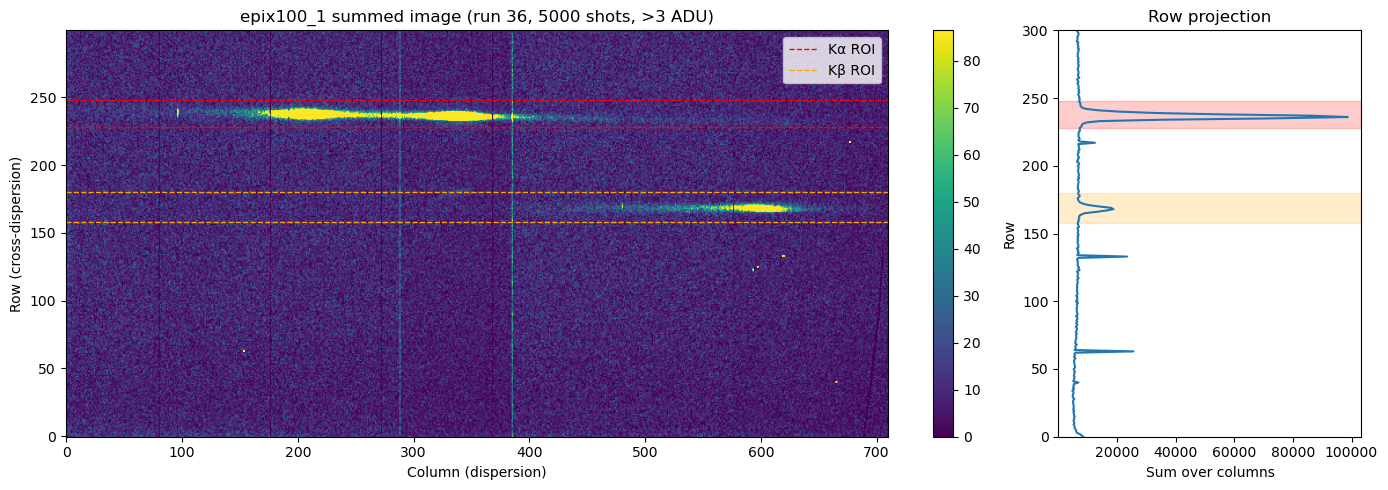

In [4]:
import h5py

DIAG_RUN = 36            # which run to show the detector image for
n_diag = 5000            # shots to sum for the diagnostic image

diag_run = runs[DIAG_RUN]
with h5py.File(diag_run.run_file, 'r') as fh:
    chunk = fh['epix100_1/ROI_area'][:n_diag]
img = np.where(chunk > 3.0, chunk, 0).sum(axis=0)  # (300 rows, 710 cols)

ka_rows = [228, 248]   # must match rois[0] in the YAML (Fe Kα)
kb_rows = [158, 180]   # must match rois[1] in the YAML (Fe Kβ)

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
im = ax.imshow(img, aspect='auto', origin='lower',
               vmax=np.percentile(img, 99.5), cmap='viridis')
for (lo, hi), c, lbl in [(ka_rows, 'red', 'Kα ROI'), (kb_rows, 'orange', 'Kβ ROI')]:
    ax.axhline(lo, color=c, ls='--', lw=1)
    ax.axhline(hi, color=c, ls='--', lw=1, label=lbl)
ax.set_xlabel('Column (dispersion)')
ax.set_ylabel('Row (cross-dispersion)')
ax.set_title(f'epix100_1 summed image (run {DIAG_RUN}, {min(n_diag, shots[DIAG_RUN])} shots, >3 ADU)')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
row_prof = img.sum(axis=1)
ax.plot(row_prof, np.arange(len(row_prof)))
for (lo, hi), c in [(ka_rows, 'red'), (kb_rows, 'orange')]:
    ax.axhspan(lo, hi, color=c, alpha=0.2)
ax.set_xlabel('Sum over columns')
ax.set_ylabel('Row')
ax.set_title('Row projection')
ax.set_ylim(0, len(row_prof))
plt.tight_layout()
plt.show()

## 2. Fe Kα emission spectrum — per-run grid

One panel per run. Each is area-normalized so peak shape is comparable
regardless of shot count. Dotted lines mark tabulated Kα1 (6404 eV) and
Kα2 (6391 eV).

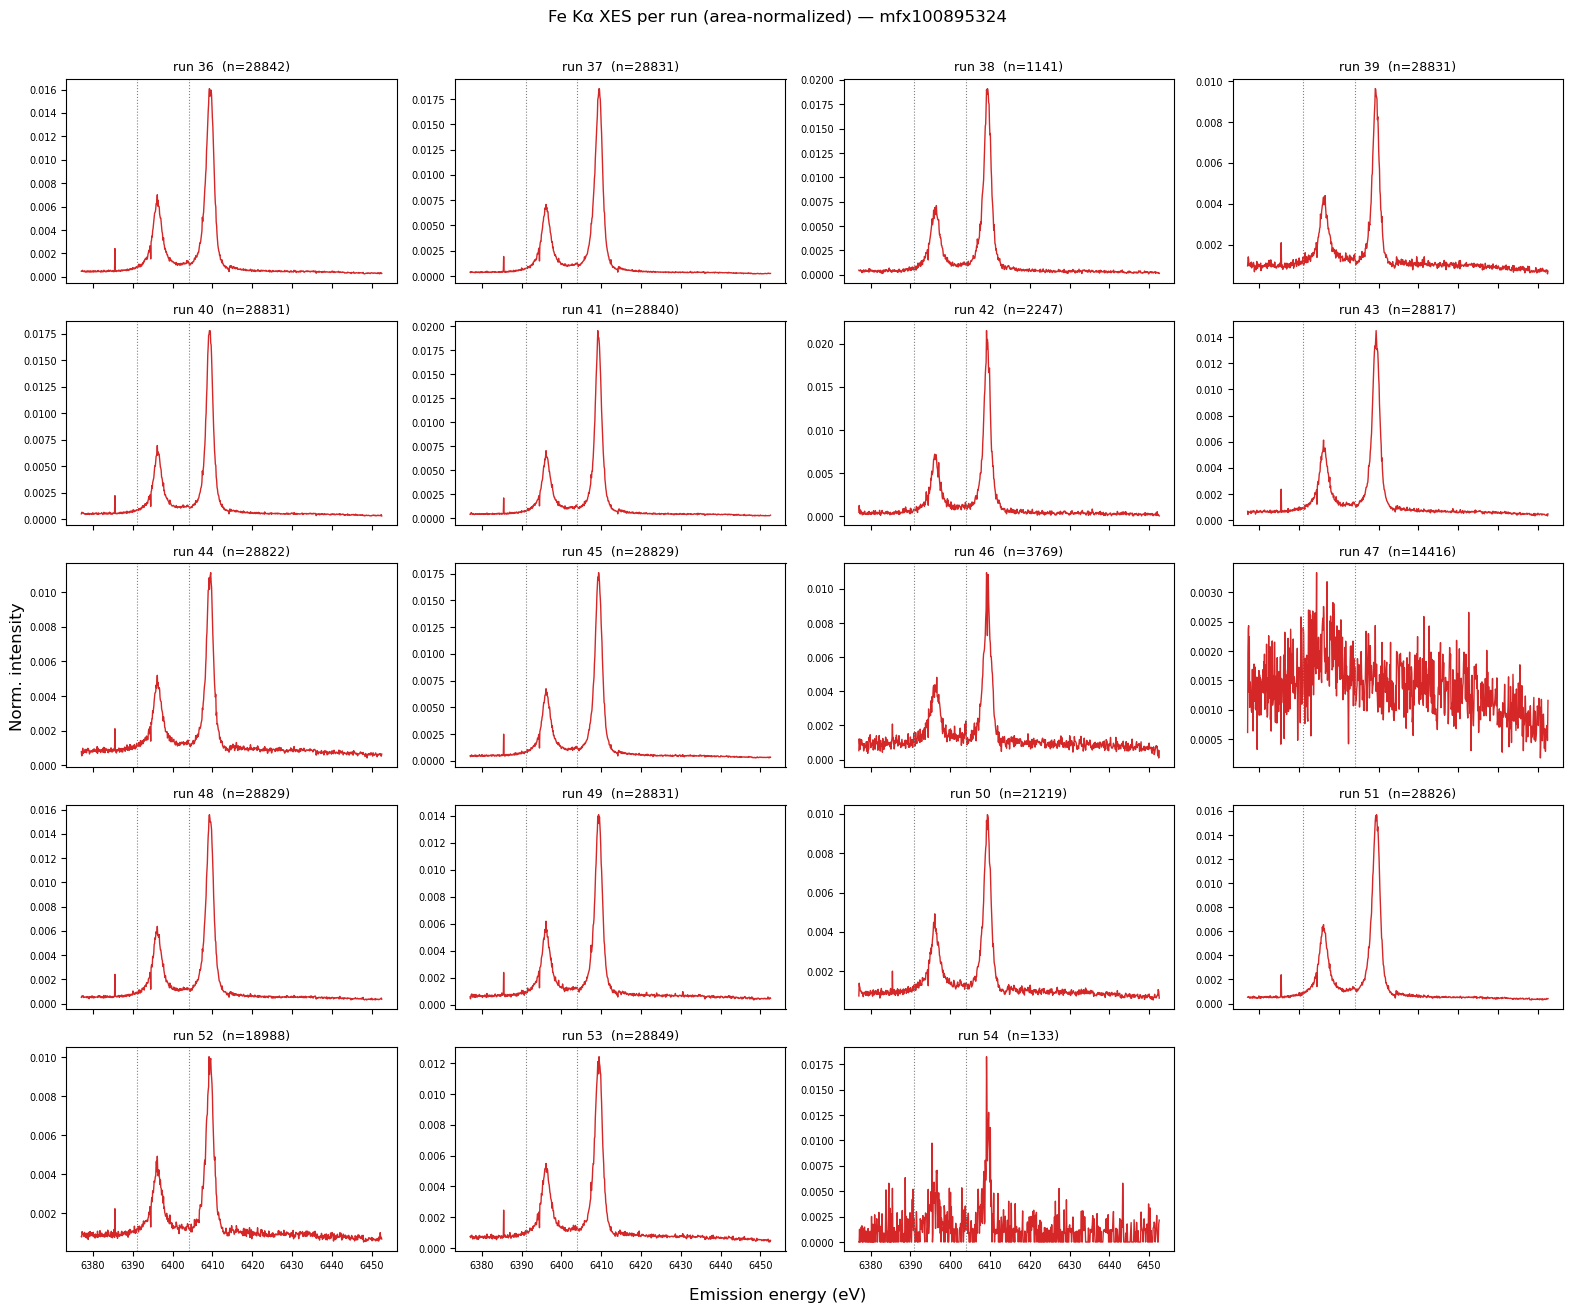

In [5]:
def area_norm(y):
    y = np.asarray(y, dtype=float)
    tot = np.nansum(y)
    return y / tot if tot > 0 else y

def combined_ref(spectra, ref_runs=None):
    """Area-normalized reference from a COMBINATION of runs.

    Sums the raw per-run spectra (photon-weighted, so high-statistics runs
    contribute more) and then area-normalizes -- identical to how the reduced
    Fe(II) end-member is built in the LCF. Defaults to REFERENCE_RUNS
    (the ferricyanide / 0% reduced runs).
    """
    if ref_runs is None:
        ref_runs = REFERENCE_RUNS
    return area_norm(np.nansum([spectra[rn] for rn in ref_runs], axis=0))

def per_run_grid(spectra, energy, ref_lines, title, color):
    n = len(spectra)
    ncol = 4
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.6 * nrow),
                             sharex=True, squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)
    for i, rn in enumerate(sorted(spectra)):
        ax = axes.flat[i]
        ax.set_visible(True)
        ax.plot(energy, area_norm(spectra[rn]), color=color, lw=1)
        for e in ref_lines:
            ax.axvline(e, color='gray', ls=':', lw=0.8)
        ax.set_title(f'run {rn}  (n={shots[rn]})', fontsize=9)
        ax.tick_params(labelsize=7)
    fig.suptitle(title, y=1.005)
    fig.supxlabel('Emission energy (eV)')
    fig.supylabel('Norm. intensity')
    plt.tight_layout()
    plt.show()

per_run_grid(ka, ka_energy, [6404, 6391],
             'Fe K\u03b1 XES per run (area-normalized) \u2014 mfx100895324', 'C3')

## 3. Fe Kβ emission spectrum — per-run grid

Dotted line marks tabulated Kβ (7058 eV). Kβ is weaker than Kα, so short
runs (few shots) will look noisier.

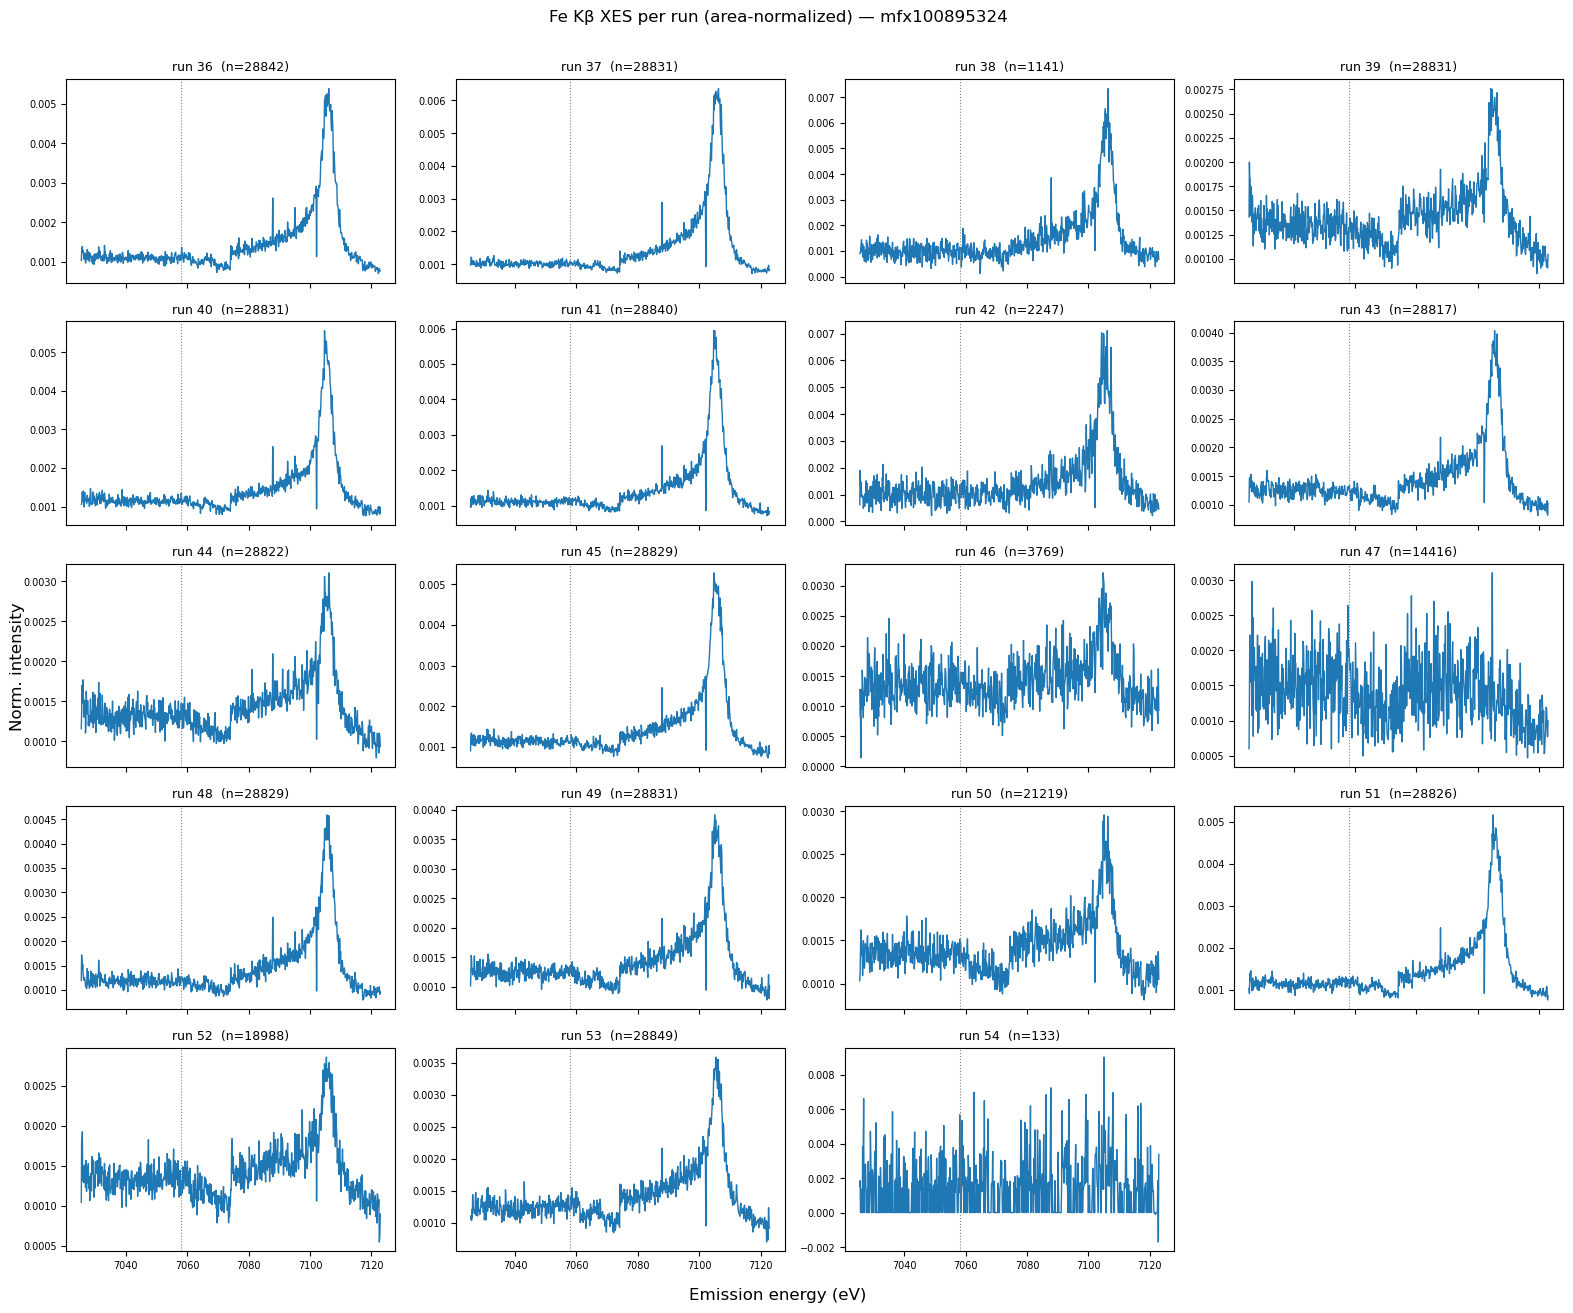

In [6]:
per_run_grid(kb, kb_energy, [7058],
             'Fe Kβ XES per run (area-normalized) — mfx100895324', 'C0')

## 4. Per-run overlay (all runs on one axis)

Area-normalized spectra overlaid, colored by run number. Good for spotting
run-to-run drift or outliers at a glance.

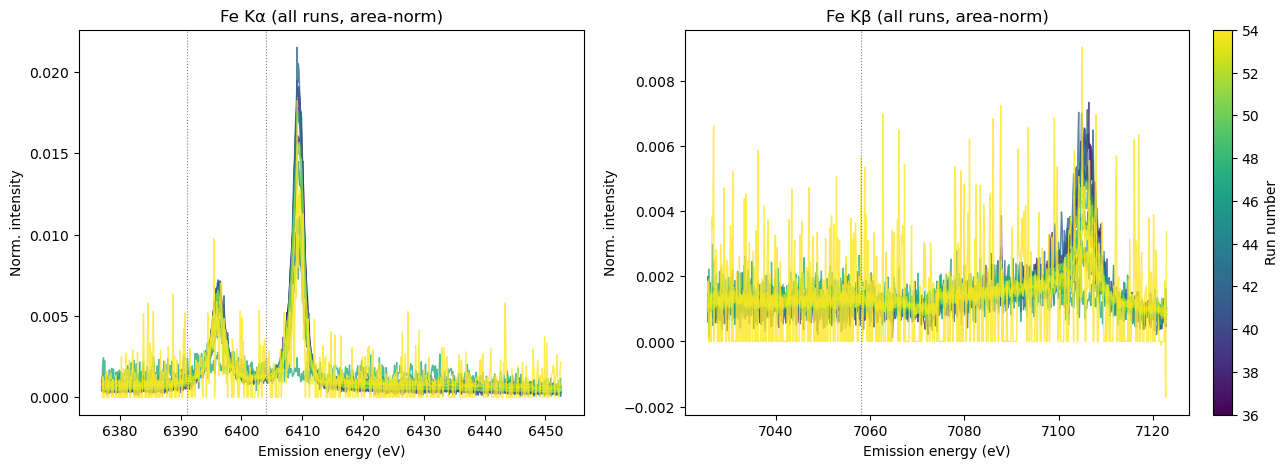

In [7]:
cmap = plt.cm.viridis
cnorm = plt.Normalize(min(run_nums), max(run_nums))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for rn in run_nums:
    c = cmap(cnorm(rn))
    axes[0].plot(ka_energy, area_norm(ka[rn]), color=c, lw=1, alpha=0.8)
    axes[1].plot(kb_energy, area_norm(kb[rn]), color=c, lw=1, alpha=0.8)

for e in (6404, 6391):
    axes[0].axvline(e, color='gray', ls=':', lw=0.8)
axes[1].axvline(7058, color='gray', ls=':', lw=0.8)

axes[0].set_title('Fe Kα (all runs, area-norm)')
axes[1].set_title('Fe Kβ (all runs, area-norm)')
for ax in axes:
    ax.set_xlabel('Emission energy (eV)')
    ax.set_ylabel('Norm. intensity')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=cnorm)
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Run number', fraction=0.025, pad=0.02)
plt.show()

## 5. Run-to-run stability — peak position vs run

Intensity-weighted peak centroid (over pixels above half-max) for each run.
Flat trends = stable spectrometer; jumps flag alignment/energy drift. Short
runs (low shot count) have noisier centroids.

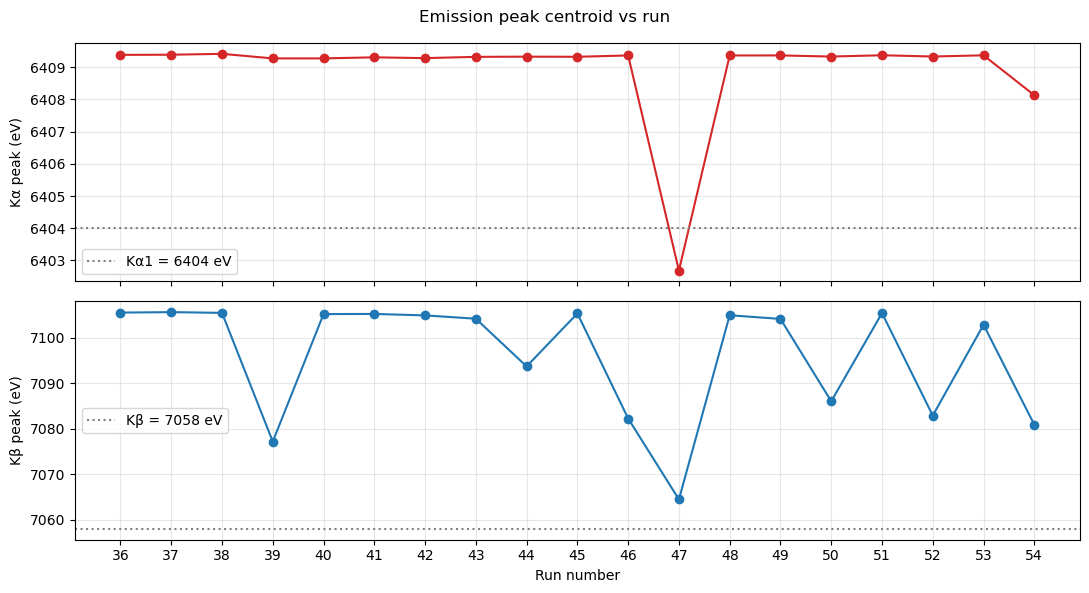

Kα peak: mean=6408.9 eV, spread=1.49 eV (expect ~6404)
Kβ peak: mean=7096.1 eV, spread=12.56 eV (expect ~7058)


In [8]:
def peak_energy(energy_axis, spectrum):
    """Intensity-weighted centroid over pixels above half-max."""
    y = np.asarray(spectrum, dtype=float)
    y = np.where(np.isfinite(y), y, 0.0)
    if y.max() <= 0:
        return np.nan
    m = y >= y.max() * 0.5
    return np.sum(energy_axis[m] * y[m]) / np.sum(y[m])

ka_peaks = np.array([peak_energy(ka_energy, ka[rn]) for rn in run_nums])
kb_peaks = np.array([peak_energy(kb_energy, kb[rn]) for rn in run_nums])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(run_nums, ka_peaks, 'o-', color='C3')
axes[0].axhline(6404, color='gray', ls=':', label='Kα1 = 6404 eV')
axes[0].set_ylabel('Kα peak (eV)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(run_nums, kb_peaks, 'o-', color='C0')
axes[1].axhline(7058, color='gray', ls=':', label='Kβ = 7058 eV')
axes[1].set_ylabel('Kβ peak (eV)'); axes[1].set_xlabel('Run number')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xticks(run_nums)

fig.suptitle('Emission peak centroid vs run')
plt.tight_layout()
plt.show()

print(f'Kα peak: mean={np.nanmean(ka_peaks):.1f} eV, spread={np.nanstd(ka_peaks):.2f} eV (expect ~6404)')
print(f'Kβ peak: mean={np.nanmean(kb_peaks):.1f} eV, spread={np.nanstd(kb_peaks):.2f} eV (expect ~7058)')

## 6. Percent deviation from reference — IAD

**Integrated Absolute Difference** (Vankó et al.), the standard scalar metric
for Kβ XES redox series. Each spectrum is area-normalized, then

$$\mathrm{IAD}_i = \sum_E \lvert S_i(E) - S_{\mathrm{ref}}(E)\rvert$$

Because area-normalized spectra integrate to 1, IAD is a fractional change;
×100 gives **percent spectral change** vs the ferricyanide reference. The
reference is the **combined ferricyanide runs (36–38)** — raw counts summed,
then area-normalized — for lower noise. IAD is monotonic with degree of
reduction, so it should track the nominal Fe(II) fraction. Computed for both
Kα and Kβ. Run 47 (Fe foil) is shown separately as a sanity check — it
should be a large outlier.

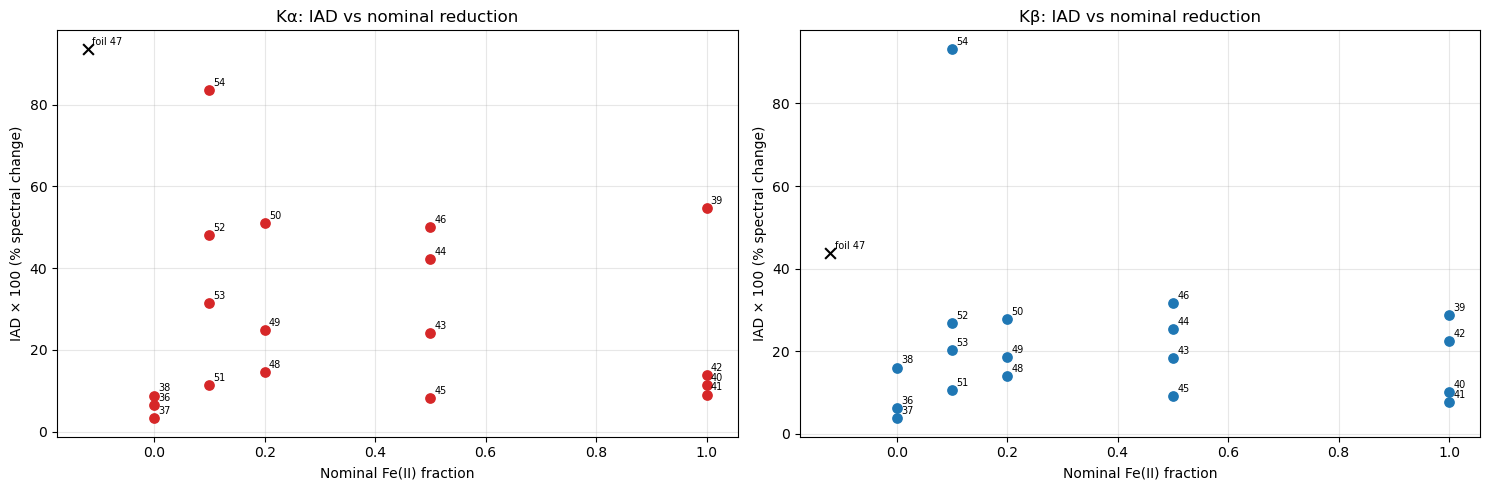

Reference = combined ferricyanide runs [36, 37, 38]
run  label       nominal   IAD_Kα%   IAD_Kβ%
 36  Fe(III)        0.00     6.44     6.23
 37  Fe(III)        0.00     3.25     3.80
 38  Fe(III)        0.00     8.78    16.05
 39  Fe(II)         1.00    54.73    28.68
 40  Fe(II)         1.00    11.31    10.23
 41  Fe(II)         1.00     9.03     7.80
 42  Fe(II)         1.00    13.91    22.48
 43  Fe(II):Fe(III)_50:50     0.50    24.15    18.34
 44  Fe(II):Fe(III)_50:50     0.50    42.30    25.36
 45  Fe(II):Fe(III)_50:50     0.50     8.11     9.20
 46  Fe(II):Fe(III)_50:50     0.50    50.01    31.67
 47  Fe_Foil      (foil)    93.66    43.76
 48  Fe(II):Fe(III)_20:80     0.20    14.58    13.98
 49  Fe(II):Fe(III)_20:80     0.20    24.86    18.55
 50  Fe(II):Fe(III)_20:80     0.20    50.94    27.75
 51  Fe(II):Fe(III)_10:90     0.10    11.29    10.69
 52  Fe(II):Fe(III)_10:90     0.10    48.13    26.75
 53  Fe(II):Fe(III)_10:90     0.10    31.52    20.25
 54  Fe(II):Fe(III)_10:90    

In [9]:
def iad(spectra, runs_list, ref=None):
    if ref is None:
        ref = combined_ref(spectra)          # combined ferricyanide reference
    return {rn: float(np.nansum(np.abs(area_norm(spectra[rn]) - ref))) for rn in runs_list}

# Combined reference (runs 36-38) computed once per line, reused for every run.
ref_ka = combined_ref(ka)
ref_kb = combined_ref(kb)

# IAD for all runs (incl. foil) so we can show the foil as an outlier
iad_ka = iad(ka, run_nums, ref=ref_ka)
iad_kb = iad(kb, run_nums, ref=ref_kb)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, iadv, lbl, col in [(axes[0], iad_ka, 'K\u03b1', 'C3'),
                           (axes[1], iad_kb, 'K\u03b2', 'C0')]:
    # nominal reduced fraction on x for cyanide runs; foil plotted at x=-0.1
    xs = [reduced_fraction[rn] for rn in chem_runs]
    ys = [100 * iadv[rn] for rn in chem_runs]
    ax.scatter(xs, ys, c=col, s=45, zorder=3)
    for rn in chem_runs:
        ax.annotate(str(rn), (reduced_fraction[rn], 100 * iadv[rn]),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')
    for rn in FOIL_RUNS:
        ax.scatter([-0.12], [100 * iadv[rn]], marker='x', c='k', s=60, zorder=3)
        ax.annotate(f'foil {rn}', (-0.12, 100 * iadv[rn]), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Nominal Fe(II) fraction'); ax.set_ylabel('IAD \u00d7 100 (% spectral change)')
    ax.set_title(f'{lbl}: IAD vs nominal reduction'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Reference = combined ferricyanide runs {REFERENCE_RUNS}')
print('run  label       nominal   IAD_K\u03b1%   IAD_K\u03b2%')
for rn in run_nums:
    tag = '(foil)' if rn in FOIL_RUNS else f'{reduced_fraction.get(rn, np.nan):.2f}'
    print(f'{rn:3d}  {sample_label[rn]:10s}  {tag:>7s}   {100*iad_ka[rn]:6.2f}   {100*iad_kb[rn]:6.2f}')

## 7. Fraction reduced — two-component linear-combination fit (LCF)

Fit each cyanide spectrum as a mixture of the oxidized reference and the
fully-reduced Fe(II) end-member:

$$S_i(E) = f_i\, S_{\mathrm{reduced}}(E) + (1-f_i)\, S_{\mathrm{ref}}(E)$$

The fitted $f_i$ **is** the fraction reduced. Both end-members are built the
same way — raw counts summed across runs, then area-normalized: the
**oxidized reference = ferricyanide runs 36–38** and the **reduced
end-member = ferrocyanide runs 39–42**. Combining the ferricyanide runs
gives a lower-noise reference and makes the two end-members symmetric.
Because the mixtures have known nominal compositions, plotting fitted vs
nominal fraction validates the method (ideal = the diagonal). Run 47 (foil)
is excluded.

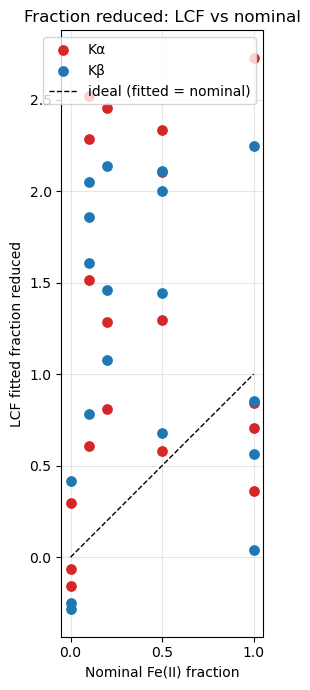

Oxidized end-member = combined runs [36, 37, 38]; reduced end-member = combined runs [39, 40, 41, 42]
run  label       nominal   f_Kα     f_Kβ
 36  Fe(III)       0.00    29.8%    41.8%
 37  Fe(III)       0.00   -15.5%   -24.9%
 38  Fe(III)       0.00    -6.2%   -28.4%
 39  Fe(II)        1.00   272.8%   224.8%
 40  Fe(II)        1.00    84.2%    85.2%
 41  Fe(II)        1.00    70.4%    56.5%
 42  Fe(II)        1.00    36.2%     4.0%
 43  Fe(II):Fe(III)_50:50    0.50   129.3%   144.5%
 44  Fe(II):Fe(III)_50:50    0.50   210.2%   200.2%
 45  Fe(II):Fe(III)_50:50    0.50    58.1%    68.1%
 46  Fe(II):Fe(III)_50:50    0.50   233.4%   211.0%
 48  Fe(II):Fe(III)_20:80    0.20    81.1%   107.5%
 49  Fe(II):Fe(III)_20:80    0.20   128.2%   146.2%
 50  Fe(II):Fe(III)_20:80    0.20   245.6%   213.9%
 51  Fe(II):Fe(III)_10:90    0.10    60.6%    78.1%
 52  Fe(II):Fe(III)_10:90    0.10   228.6%   204.9%
 53  Fe(II):Fe(III)_10:90    0.10   151.3%   160.8%
 54  Fe(II):Fe(III)_10:90    0.10   251.7% 

In [10]:
from numpy.linalg import lstsq

REDUCED_RUNS = [39, 40, 41, 42]   # pure Fe(II) ferrocyanide end-member

def lcf_fraction(spectra, energy):
    # Both end-members built the same way: sum raw counts -> area-normalize.
    ref = combined_ref(spectra, REFERENCE_RUNS)   # oxidized Fe(III), runs 36-38
    red = combined_ref(spectra, REDUCED_RUNS)     # reduced  Fe(II),  runs 39-42
    # Model matrix columns: [reduced, oxidized]; fit S = f*red + (1-f)*ref
    # => S - ref = f*(red - ref)  -> single-parameter least squares
    basis = (red - ref)
    fracs = {}
    for rn in chem_runs:
        y = area_norm(spectra[rn]) - ref
        f = float(np.dot(basis, y) / np.dot(basis, basis))
        fracs[rn] = f
    return fracs

f_ka = lcf_fraction(ka, ka_energy)
f_kb = lcf_fraction(kb, kb_energy)

fig, ax = plt.subplots(figsize=(7, 7))
for fv, lbl, col in [(f_ka, 'K\u03b1', 'C3'), (f_kb, 'K\u03b2', 'C0')]:
    xs = [reduced_fraction[rn] for rn in chem_runs]
    ys = [fv[rn] for rn in chem_runs]
    ax.scatter(xs, ys, c=col, s=45, label=lbl, zorder=3)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='ideal (fitted = nominal)')
ax.set_xlabel('Nominal Fe(II) fraction'); ax.set_ylabel('LCF fitted fraction reduced')
ax.set_title('Fraction reduced: LCF vs nominal'); ax.legend(); ax.grid(alpha=0.3)
ax.set_aspect('equal'); plt.tight_layout(); plt.show()

print(f'Oxidized end-member = combined runs {REFERENCE_RUNS}; '
      f'reduced end-member = combined runs {REDUCED_RUNS}')
print('run  label       nominal   f_K\u03b1     f_K\u03b2')
for rn in chem_runs:
    print(f'{rn:3d}  {sample_label[rn]:10s}  {reduced_fraction[rn]:6.2f}   '
          f'{100*f_ka[rn]:5.1f}%   {100*f_kb[rn]:5.1f}%')

## 8. Pointwise % deviation vs energy

Energy-resolved percent difference $100\,(S_i - S_{\mathrm{ref}})/S_{\mathrm{ref}}$
(area-normalized). Shows *where* the spectrum changes with reduction \u2014 e.g. the
K\u03b2' shoulder and the K\u03b2$_{1,3}$ energy shift. One representative run per nominal
composition; the reference is flat at zero by construction. Foil excluded.

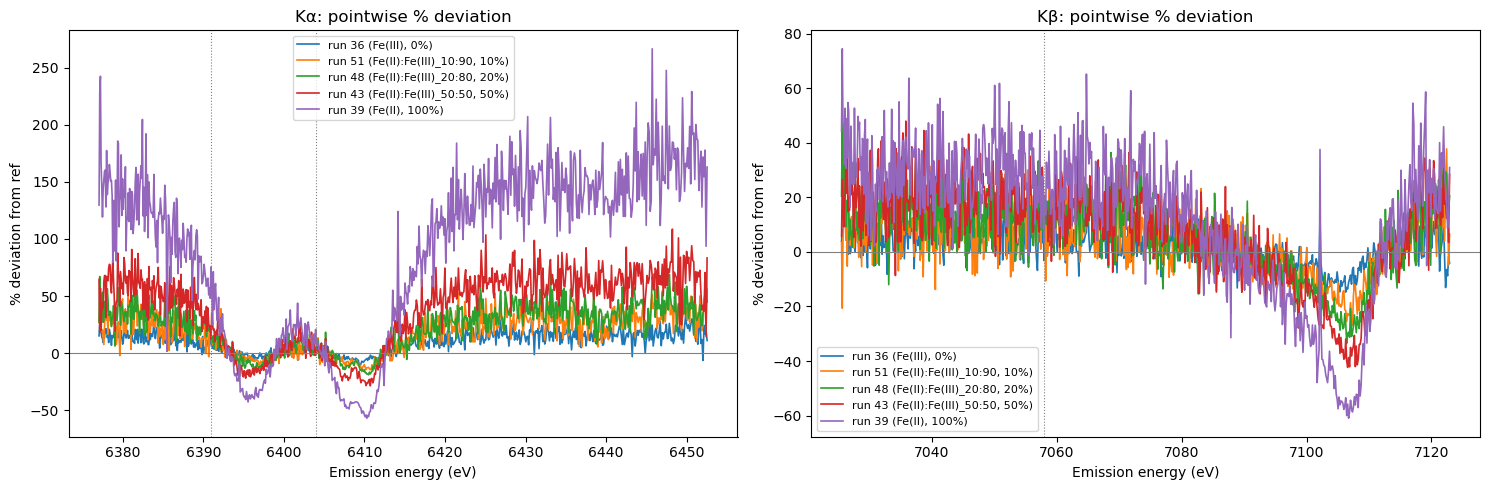

In [11]:
def pct_dev(spectra, energy, eps_frac=1e-3):
    ref = combined_ref(spectra)                        # combined ferricyanide reference
    floor = ref.max() * eps_frac                       # avoid blow-up in the tails
    safe = np.where(ref > floor, ref, np.nan)
    out = {}
    for rn in chem_runs:
        out[rn] = 100 * (area_norm(spectra[rn]) - ref) / safe
    return out

# one representative run per nominal composition (first of each group)
rep = {}
for rn in chem_runs:
    rep.setdefault(reduced_fraction[rn], rn)
rep_runs = [rep[k] for k in sorted(rep)]

pd_ka = pct_dev(ka, ka_energy)
pd_kb = pct_dev(kb, kb_energy)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, pdv, energy, lbl, refl in [
        (axes[0], pd_ka, ka_energy, 'K\u03b1', (6404, 6391)),
        (axes[1], pd_kb, kb_energy, 'K\u03b2', (7058,))]:
    for rn in rep_runs:
        ax.plot(energy, pdv[rn], lw=1.2,
                label=f'run {rn} ({sample_label[rn]}, {reduced_fraction[rn]:.0%})')
    ax.axhline(0, color='gray', lw=0.8)
    for e in refl:
        ax.axvline(e, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('Emission energy (eV)'); ax.set_ylabel('% deviation from ref')
    ax.set_title(f'{lbl}: pointwise % deviation'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. (Optional) Save per-run spectra to HDF5

`Pipeline.run()` collects results in memory but does not write to disk. Run
this cell to persist per-run spectra and the shared energy axes. Output lands
in the `results/` subdirectory (path set in the YAML).

In [12]:
out_dir = p.config.output.path
os.makedirs(out_dir, exist_ok=True)
out_file = os.path.join(out_dir, 'runs_36_54_static_xes.h5')

with h5py.File(out_file, 'w') as fh:
    fh['kalpha_energy'] = ka_energy
    fh['kbeta_energy'] = kb_energy
    for rn in run_nums:
        g = fh.create_group(f'run_{rn}')
        g['kalpha'] = ka[rn]
        g['kbeta'] = kb[rn]
        g.attrs['total_shots'] = shots[rn]
print(f'Wrote {out_file}  ({len(run_nums)} runs)')

Wrote /sdf/data/lcls/ds/mfx/mfx100895324/results/lbgee/XSpect/experiments/mfx100895324/results/runs_36_54_static_xes.h5  (19 runs)
